# Food Waste Data Analysis & Cleaning

## Project Overview

This notebook focuses on exploring and cleaning a food waste dataset before using it for further analysis and dashboard development.

The dataset contains information about food waste across different countries, years, and food categories, including:

- Total food waste
- Economic loss
- Average waste per capita
- Population
- Household waste percentage

The main objectives of this notebook are:

1. Understand the structure and characteristics of the dataset.
2. Identify data quality issues such as missing values, duplicates, inconsistent data types, and outliers.
3. Apply appropriate data cleaning techniques.
4. Document the reasoning behind every cleaning decision.
5. Validate the cleaned dataset before moving to the next stage of the project.


## Dataset Overview

In [85]:
import pandas as pd
import numpy as np
df = pd.read_csv(r'C:\Users\asd\Desktop\NTI\Graduation Project\global_food_wastage_dataset.csv')

In [86]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5000
Number of columns: 8


In [87]:
df.head()

,Country,Year,Food Category,Total Waste (Tons),Economic Loss (Million $),Avg Waste per Capita (Kg),Population (Million),Household Waste (%)
0,Australia,2019,Fruits & Vegetables,19268.63,18686.68,72.69,87.59,53.64
1,Indonesia,2019,Prepared Food,3916.97,4394.48,192.52,1153.99,30.61
2,Germany,2022,NaN,9700.16,8909.16,166.94,1006.11,48.08
3,France,2023,Fruits & Vegetables,46299.69,40551.22,120.19,NaN,31.91
4,France,2023,Beverages,33096.57,36980.82,104.74,1105.47,36.06


## Data Types

In [88]:
data_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})

data_info

,Column,Data Type,Missing Values,Missing %,Unique Values
Country,Country,object,0,0.0,20
Year,Year,int64,0,0.0,7
Food Category,Food Category,object,300,6.0,8
Total Waste (Tons),Total Waste (Tons),float64,400,8.0,4599
Economic Loss (Million $),Economic Loss (Million $),float64,0,0.0,4998
Avg Waste per Capita (Kg),Avg Waste per Capita (Kg),float64,250,5.0,4157
Population (Million),Population (Million),float64,600,12.0,4328
Household Waste (%),Household Waste (%),float64,500,10.0,2699


## Basic Statistical EDA

In [89]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,5000.0,2021.015600,1.999239,2018.00,2019.0000,2021.000,2023.0000,2024.00
Total Waste (Tons),4600.0,24876.820080,14225.141885,502.61,12616.2800,24564.630,37226.6725,49990.76
Economic Loss (Million $),5000.0,25039.703870,14620.236429,406.69,12612.4775,24428.155,37146.0375,59228.93
Avg Waste per Capita (Kg),4750.0,109.411886,51.832003,20.09,64.0625,110.155,153.9825,199.92
Population (Million),4400.0,708.453293,403.694512,11.46,350.6025,719.055,1060.4475,1399.97
Household Waste (%),4500.0,50.113031,11.598478,30.02,40.0975,50.420,60.2425,70.00


In [90]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(10))


--- Country ---
Country
Germany    287
Spain      274
China      262
Brazil     258
India      257
USA        257
Turkey     256
Canada     254
Italy      253
Mexico     251
Name: count, dtype: int64

--- Food Category ---
Food Category
Prepared Food          666
Beverages              603
Fruits & Vegetables    582
Bakery Items           579
Dairy Products         575
Meat & Seafood         574
Frozen Food            564
Grains & Cereals       557
NaN                    300
Name: count, dtype: int64


## Missing Values Analysis

In [91]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

missing_summary

,Missing Count,Missing Percentage
Population (Million),600,12.0
Household Waste (%),500,10.0
Total Waste (Tons),400,8.0
Food Category,300,6.0
Avg Waste per Capita (Kg),250,5.0


### Missing Values Assessment

Missing values were found in five columns.

The highest missing-value percentage is observed in `Population (Million)` at 12%, followed by `Household Waste (%)` at 10%.

Rows will not be removed automatically because deleting all incomplete observations could result in a significant loss of data and may introduce bias.

Instead, missing values will be handled according to the data type and the meaning of each variable.

In [92]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Assessment

No completely duplicated rows were identified in the dataset.

Therefore, no rows were removed based on duplicate detection.

## Check Categorical Values

In [93]:
print(df["Country"].nunique())
print(df["Food Category"].nunique())

20
8


## Check Numeric Ranges

In [94]:
print("Negative Total Waste:",
      (df["Total Waste (Tons)"] < 0).sum())

print("Negative Economic Loss:",
      (df["Economic Loss (Million $)"] < 0).sum())

print("Negative Population:",
      (df["Population (Million)"] < 0).sum())

print("Negative Avg Waste per Capita:",
      (df["Avg Waste per Capita (Kg)"] < 0).sum())

Negative Total Waste: 0
Negative Economic Loss: 0
Negative Population: 0
Negative Avg Waste per Capita: 0


### Outliers Assessment

The IQR method was used to detect potential outliers in the numerical columns.

No outliers were detected in the dataset. Therefore, no outlier removal or transformation was required.

In [95]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(col, ":", outliers, "outliers")

Year : 0 outliers
Total Waste (Tons) : 0 outliers
Economic Loss (Million $) : 0 outliers


Avg Waste per Capita (Kg) : 0 outliers
Population (Million) : 0 outliers
Household Waste (%) : 0 outliers


In [96]:
# Copy original data for Power BI
df_clean = df.copy()

# 1. Population → Country + Year
df_clean["Population (Million)"] = df_clean["Population (Million)"].fillna(
    df_clean.groupby(["Country", "Year"])["Population (Million)"].transform("median")
)
df_clean["Population (Million)"] = df_clean["Population (Million)"].fillna(
    df_clean["Population (Million)"].median()
)

# 2. Total Waste → Country + Food Category
df_clean["Total Waste (Tons)"] = df_clean["Total Waste (Tons)"].fillna(
    df_clean.groupby(["Country", "Food Category"])["Total Waste (Tons)"].transform("median")
)
df_clean["Total Waste (Tons)"] = df_clean["Total Waste (Tons)"].fillna(
    df_clean["Total Waste (Tons)"].median()
)

# 3. Avg Waste per Capita → Country + Food Category
df_clean["Avg Waste per Capita (Kg)"] = df_clean["Avg Waste per Capita (Kg)"].fillna(
    df_clean.groupby(["Country", "Food Category"])["Avg Waste per Capita (Kg)"].transform("median")
)
df_clean["Avg Waste per Capita (Kg)"] = df_clean["Avg Waste per Capita (Kg)"].fillna(
    df_clean["Avg Waste per Capita (Kg)"].median()
)

# 4. Household Waste → Country
df_clean["Household Waste (%)"] = df_clean["Household Waste (%)"].fillna(
    df_clean.groupby("Country")["Household Waste (%)"].transform("median")
)
df_clean["Household Waste (%)"] = df_clean["Household Waste (%)"].fillna(
    df_clean["Household Waste (%)"].median()
)

# 5. Food Category → Mode
df_clean["Food Category"] = df_clean["Food Category"].fillna(
    df_clean["Food Category"].mode()[0]
)

# Check missing values
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

# Save cleaned data for Power BI
df_clean.to_csv("Food_Waste_Cleaned_PowerBI.csv", index=False)

print("\nFile saved successfully!")

Missing values after cleaning:
Country                      0
Year                         0
Food Category                0
Total Waste (Tons)           0
Economic Loss (Million $)    0
Avg Waste per Capita (Kg)    0
Population (Million)         0
Household Waste (%)          0
dtype: int64

File saved successfully!


###  Train/Test Split

In [97]:
from sklearn.model_selection import train_test_split

X = df.drop("Economic Loss (Million $)", axis=1)
y = df["Economic Loss (Million $)"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [98]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 7)
X_test: (1000, 7)
y_train: (4000,)
y_test: (1000,)


## Missing Values Treatment

The dataset was split into training and testing sets before handling missing values to prevent **data leakage**.

Missing numerical values were handled using **grouping-based median imputation**:

- `Population (Million)` → grouped by **Country + Year**
- `Total Waste (Tons)` → grouped by **Country + Food Category**
- `Avg Waste per Capita (Kg)` → grouped by **Country + Food Category**
- `Household Waste (%)` → grouped by **Country**

If a group did not have a valid median, the **global median from the training set** was used as a fallback.

For `Food Category`, missing values were replaced with the **global mode**.

All imputation values were calculated from the **training set only** to avoid data leakage.

In [99]:
# Grouping Imputation - X_train

# 1. Population → Country + Year
pop_group_median = X_train.groupby(
    ["Country", "Year"]
)["Population (Million)"].transform("median")

X_train["Population (Million)"] = X_train["Population (Million)"].fillna(
    pop_group_median
)

# Fallback → Global Median
X_train["Population (Million)"] = X_train["Population (Million)"].fillna(
    X_train["Population (Million)"].median()
)

# 2. Total Waste → Country + Food Category
waste_group_median = X_train.groupby(
    ["Country", "Food Category"]
)["Total Waste (Tons)"].transform("median")

X_train["Total Waste (Tons)"] = X_train["Total Waste (Tons)"].fillna(
    waste_group_median
)

# Fallback → Global Median
X_train["Total Waste (Tons)"] = X_train["Total Waste (Tons)"].fillna(
    X_train["Total Waste (Tons)"].median()
)


# 3. Avg Waste per Capita → Country + Food Category
avg_group_median = X_train.groupby(
    ["Country", "Food Category"]
)["Avg Waste per Capita (Kg)"].transform("median")

X_train["Avg Waste per Capita (Kg)"] = X_train[
    "Avg Waste per Capita (Kg)"
].fillna(avg_group_median)

# Fallback → Global Median
X_train["Avg Waste per Capita (Kg)"] = X_train[
    "Avg Waste per Capita (Kg)"
].fillna(
    X_train["Avg Waste per Capita (Kg)"].median()
)

# 4. Household Waste → Country
house_group_median = X_train.groupby(
    "Country"
)["Household Waste (%)"].transform("median")

X_train["Household Waste (%)"] = X_train[
    "Household Waste (%)"
].fillna(house_group_median)

# Fallback → Global Median
X_train["Household Waste (%)"] = X_train[
    "Household Waste (%)"
].fillna(
    X_train["Household Waste (%)"].median()
)

# 5. Food Category → Global Mode
X_train["Food Category"] = X_train["Food Category"].fillna(
    X_train["Food Category"].mode()[0]
)

# Check Missing Values

print("Missing values after imputation:")
print(X_train.isnull().sum())

Missing values after imputation:
Country                      0
Year                         0
Food Category                0
Total Waste (Tons)           0
Avg Waste per Capita (Kg)    0
Population (Million)         0
Household Waste (%)          0
dtype: int64


In [100]:
# Imputation for X_test
# Statistics are calculated from X_train only

# Population → Country + Year
pop_median = X_train.groupby(
    ["Country", "Year"]
)["Population (Million)"].median()

X_test["Population (Million)"] = X_test.apply(
    lambda row: pop_median.get((row["Country"], row["Year"]), 
                               X_train["Population (Million)"].median())
    if pd.isna(row["Population (Million)"]) else row["Population (Million)"],
    axis=1
)

# Total Waste → Country + Food Category
waste_median = X_train.groupby(
    ["Country", "Food Category"]
)["Total Waste (Tons)"].median()

X_test["Total Waste (Tons)"] = X_test.apply(
    lambda row: waste_median.get((row["Country"], row["Food Category"]),
                                 X_train["Total Waste (Tons)"].median())
    if pd.isna(row["Total Waste (Tons)"]) else row["Total Waste (Tons)"],
    axis=1
)

# Avg Waste per Capita → Country + Food Category
avg_median = X_train.groupby(
    ["Country", "Food Category"]
)["Avg Waste per Capita (Kg)"].median()

X_test["Avg Waste per Capita (Kg)"] = X_test.apply(
    lambda row: avg_median.get((row["Country"], row["Food Category"]),
                               X_train["Avg Waste per Capita (Kg)"].median())
    if pd.isna(row["Avg Waste per Capita (Kg)"]) else row["Avg Waste per Capita (Kg)"],
    axis=1
)

# Household Waste → Country
house_median = X_train.groupby(
    "Country"
)["Household Waste (%)"].median()

X_test["Household Waste (%)"] = X_test.apply(
    lambda row: house_median.get(row["Country"],
                                 X_train["Household Waste (%)"].median())
    if pd.isna(row["Household Waste (%)"]) else row["Household Waste (%)"],
    axis=1
)

# Food Category → Global Mode from X_train
X_test["Food Category"] = X_test["Food Category"].fillna(
    X_train["Food Category"].mode()[0]
)

# Check
print("Missing values in X_test:")
print(X_test.isnull().sum())

Missing values in X_test:
Country                      0
Year                         0
Food Category                0
Total Waste (Tons)           0
Avg Waste per Capita (Kg)    0
Population (Million)         0
Household Waste (%)          0
dtype: int64


## Categorical Encoding

One-Hot Encoding was applied to the categorical features `Country` and `Food Category`.

The encoder was fitted on the training data and then applied to the test data to prevent data leakage.

`handle_unknown="ignore"` was used to handle any category that may appear in the test set but was not present in the training set.

In [101]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["Country", "Food Category"]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

print("Train encoded shape:", X_train_cat.shape)
print("Test encoded shape:", X_test_cat.shape)

Train encoded shape: (4000, 28)
Test encoded shape: (1000, 28)


## Numerical Feature Scaling

StandardScaler was applied to the numerical features to standardize their scale.

The scaler was fitted on the training data only and then applied to the test data to prevent data leakage.

In [102]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    "Year",
    "Total Waste (Tons)",
    "Avg Waste per Capita (Kg)",
    "Population (Million)",
    "Household Waste (%)"
]

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

print("Train scaled shape:", X_train_num.shape)
print("Test scaled shape:", X_test_num.shape)

Train scaled shape: (4000, 5)
Test scaled shape: (1000, 5)


In [103]:
X_train_final = np.hstack([
    X_train_num,
    X_train_cat
])

X_test_final = np.hstack([
    X_test_num,
    X_test_cat
])

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Final train shape: (4000, 33)
Final test shape: (1000, 33)


In [104]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](33,)","[ -52.94,14133.99, -47.38,..., -290.94, -39.14, -69.24]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.498e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,33
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(31)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](33,)","[64.41,64.14,63.66,...,13.35, 0. , 0. ]"


In [105]:
y_pred = model.predict(X_test_final)

In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 6734.715098657865
MSE: 106144200.55282654
RMSE: 10302.630758831772
R2: 0.5331983305434327


In [107]:
accuracy = r2_score(y_test, y_pred) * 100

print("Linear Regression Accuracy:", accuracy, "%")

Linear Regression Accuracy: 53.31983305434327 %


In [112]:
median_loss = y_train.median()

y_train_log = (y_train >= median_loss).astype(int)
y_test_log = (y_test >= median_loss).astype(int)

In [113]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_final, y_train_log)

y_pred_log = log_model.predict(X_test_final)

In [114]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test_log, y_pred_log)
precision = precision_score(y_test_log, y_pred_log)
recall = recall_score(y_test_log, y_pred_log)
f1 = f1_score(y_test_log, y_pred_log)

print("Logistic Regression")
print("----------------------")
print("Accuracy:", accuracy)
print("Accuracy %:", accuracy * 100)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log))

Logistic Regression
----------------------
Accuracy: 0.778
Accuracy %: 77.8
Precision: 0.8038379530916845
Recall: 0.7435897435897436
F1 Score: 0.7725409836065574

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       493
           1       0.80      0.74      0.77       507

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000



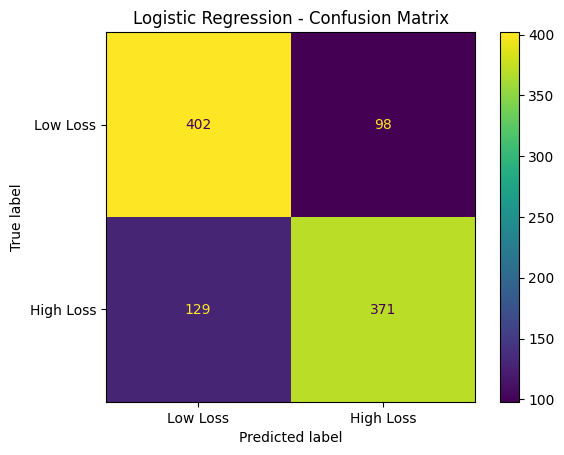

In [111]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_log, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Loss", "High Loss"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [115]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](33,)","[ -52.94,14133.99, -47.38,..., -290.94, -39.14, -69.24]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.498e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,33
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(31)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](33,)","[64.41,64.14,63.66,...,13.35, 0. , 0. ]"


In [116]:
import joblib

joblib.dump(model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [117]:
log_model
joblib.dump(log_model, "logistic_regression_model.pkl")

['logistic_regression_model.pkl']